# LoneStar Wireless — Customer Churn Analysis
## Executive Summary

### Purpose
LoneStar Wireless wanted to know why there's a sizable churn rate among their customers and how they could mitigate this.

### Key Findings
1. 43% of the churn rate comes from Month-to-Month customers. Compare that to the Yearly at a 11% and Two-Year at 3%, a sizable amount of customers are leaving for other services.
2 Singles consists the largest churn rate at 32%. Customers with only a partner (25%) or only dependents (21%) fall in between. The smallest group is customers with families at 14%.
3. The overall findings show that singles or customers in smaller groups are most likely to churn from contracts.

### Recommendations
1. Offer a percentage deal when signing into long-term contract.
2. Prioritize singles and customers living in smaller groups.

### Next Steps
Analyze whether streaming, Internet, and phone services influence churn rate
Investigate whether tech support access reduces churn among high-risk groups
Collect customer exit survey data to understand WHY customers are leaving, not just who is leaving

In [0]:
pip install pandas matplotlib seaborn

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd

df = spark.table("workspace.default.customer_churn_dataset").toPandas()
display(df.head(10))

customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,numAdminTickets,numTechTickets,Churn
7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000000000000,29.85,0,0,No
5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000000000000,1889.5,0,0,No
3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000000000000,108.15,0,0,Yes
7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000000000000,1840.75,0,3,No
9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000000000000,151.65,0,0,Yes
9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.650000000000000,820.5,0,0,Yes
1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.100000000000000,1949.4,0,0,No
6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.750000000000000,301.89999999999998,0,0,No
7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.800000000000000,3046.05,0,2,Yes
6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.150000000000000,3487.95,0,0,No


The data presents that 26-27 percent of customers will churn. That is over 1800 customers LoneStar will lose over the preceding year. 

In [0]:
%sql
SELECT Churn, COUNT(*) as total_customers,
ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage
FROM customer_churn_dataset
GROUP BY Churn

Churn,total_customers,percentage
No,5174,73.46
Yes,1869,26.54


In [0]:
%sql
SELECT Contract, Churn, COUNT(*) as total_customers,
ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY Contract), 2) as percentage
FROM customer_churn_dataset
GROUP BY Contract, Churn
ORDER BY Contract, Churn

Contract,Churn,total_customers,percentage
Month-to-month,No,2220,57.29
Month-to-month,Yes,1655,42.71
One year,No,1307,88.73
One year,Yes,166,11.27
Two year,No,1647,97.17
Two year,Yes,48,2.83


As the data shows, 42-43% of customers will churn out with a Month-to-Month contract. Compared to Yearly and Two-Year contracts, the churn rate is less than 15%. The recommendation is to provide discounts for the first yearly or Two-Year service. Another recommendation is to provide recipients with bundles of streaming services. 

In [0]:
%sql
SELECT Partner, Dependents, Churn, COUNT(*) as total_customers,
ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(PARTITION BY Partner, Dependents), 2) as percentage
FROM customer_churn_dataset
GROUP BY Partner, Dependents, Churn
ORDER BY Partner, Dependents, Churn

Partner,Dependents,Churn,total_customers,percentage
No,No,No,2157,65.76
No,No,Yes,1123,34.24
No,Yes,No,284,78.67
No,Yes,Yes,77,21.33
Yes,No,No,1233,74.59
Yes,No,Yes,420,25.41
Yes,Yes,No,1500,85.76
Yes,Yes,Yes,249,14.24


Looking at the data, the largest churn, at 34%, is customers without partners or dependents, and the lowest churn, at 14%, are customers with partners and dependents. Customers with only a partner at 25% and dependents at 21% are almost exact and give us a clue why customers with partners and dependents are lower. It's more of a hassle to leave a plan if there's more people around the customer. As the previous data shows, there is a higher churn rate for month-to-month customers at 42-43%. The recommended action is to offer a discount to month-to-month customers to move over to yearly or biyearly services. Priority outreach should target single customers without dependents on month-to-month plans, as this group represents the highest churn risk at 34%.

In [0]:
df.dtypes

customerID          object
gender              object
SeniorCitizen        int64
Partner             object
Dependents          object
tenure               int64
PhoneService        object
MultipleLines       object
InternetService     object
OnlineSecurity      object
OnlineBackup        object
DeviceProtection    object
TechSupport         object
StreamingTV         object
StreamingMovies     object
Contract            object
PaperlessBilling    object
PaymentMethod       object
MonthlyCharges      object
TotalCharges        object
numAdminTickets      int64
numTechTickets       int64
Churn               object
dtype: object

Monthly and Total Charges are being registered as 'objects'but should register as int64 like tenure. I'll check why this is the case. 

In [0]:
df['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.89999999999998', '3046.05', '3487.95',
       '587.45000000000005', '326.8', '5681.1', '5036.3', '2686.05',
       '7895.15', '1022.95', '7382.25', '528.35', '1862.9'], dtype=object)

As the cell above shows, we are getting the correct results. However, looking at the column below, when we add == ' ' to the program, we see why TotalCharges is coming up as a string. Someone made an error and added blank spaces into 11 rows. Therefore, TotalCharges is registering as a string rather than an integer. 

In [0]:
df[df['TotalCharges'] == ' ']['TotalCharges'].count()

np.int64(11)

In [0]:
df[df['tenure'] == 0]['tenure'].count()

np.int64(11)

Looking further deep, I rechecked Excel and found 11 rows in the 'tenure' column reading 0. These 11 are new customers that the system hasn't registered in. Rather than deleting these customers from the dataset, TotalCharges was filled with 0 to reflect that they have not yet received their first bill.


In [0]:
# Replace empty spaces with NaN
df['TotalCharges'] = df['TotalCharges'].replace(' ', float('nan'))

# Convert both columns to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'])

# Check it worked
print(df[['MonthlyCharges', 'TotalCharges']].dtypes)

MonthlyCharges    float64
TotalCharges      float64
dtype: object


TotalCharges and MonthlyCharges are needed to be converted from a string to a float. 

In [0]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
numAdminTickets       int64
numTechTickets        int64
Churn                object
dtype: object

Double-check that everything is correct and remove the 11 nulls from the dataset. 

In [0]:
# Check how many nulls we have
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
numAdminTickets      0
numTechTickets       0
Churn                0
dtype: int64


In [0]:
# Fill missing TotalCharges with 0 
# (new customers haven't been billed yet)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify nulls are gone
print(df.isnull().sum().sum())

0


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_theme(style="whitegrid")

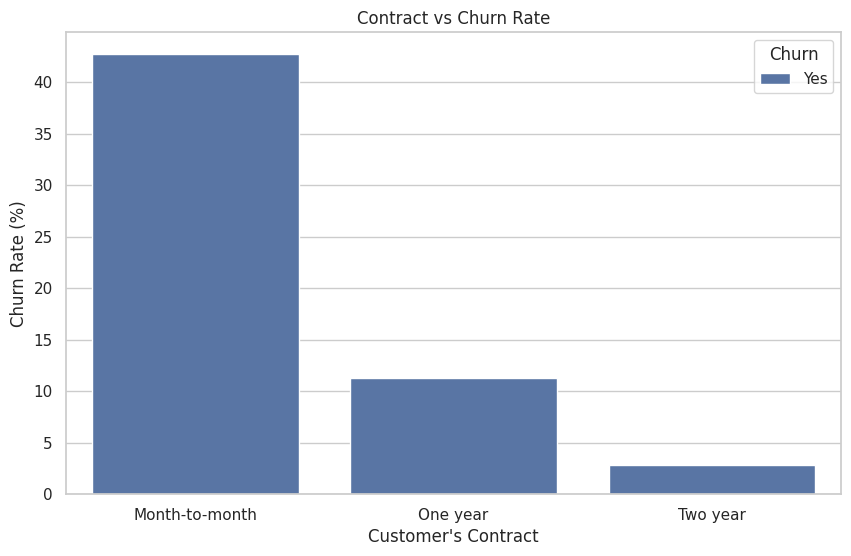

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create churn rate by contract type
churn_contract = df.groupby(['Contract', 'Churn']).size().reset_index(name='count')
churn_contract['percentage'] = churn_contract.groupby('Contract')['count'].transform(lambda x: x / x.sum() * 100)

# Chart 1 - Contract vs Churn
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_contract[churn_contract['Churn'] == 'Yes'],
            x='Contract',
            y='percentage',
            hue='Churn')

plt.title('Contract vs Churn Rate')
plt.xlabel("Customer's Contract")
plt.ylabel("Churn Rate (%)")
plt.show()

The visual above shows the percentage churn rate by the Customer's Contract length. Month-to-Month has the highest churn rate by 42% compared to 11% for One-Year contracts and 3% for Two-Year contracts. The visual above confirms the contract.

Chart 1 shows the churn rate by contract type. Month-to-month customers churn at 42%, compared to 11% for one-year and 3% for two-year contracts. This confirms that contract type is the strongest predictor of churn in this dataset.

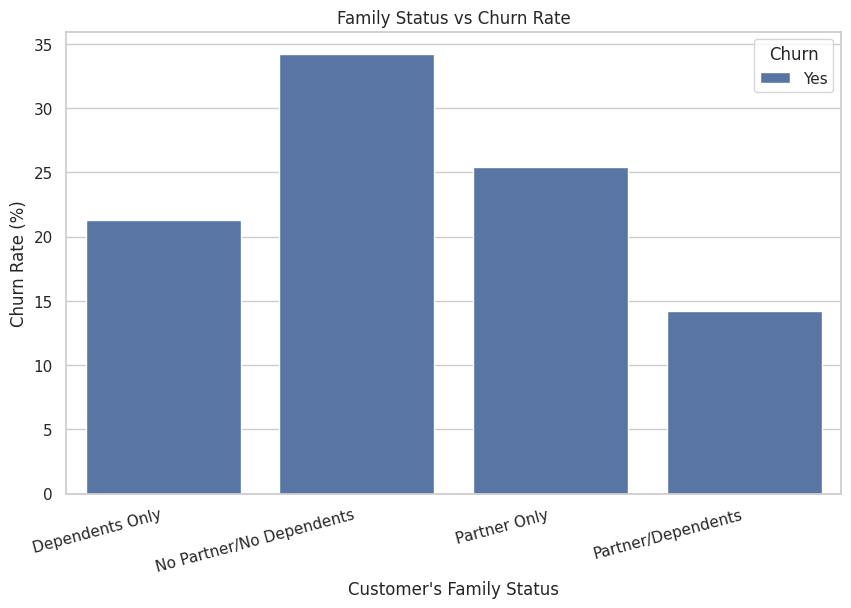

In [0]:
# Step 1 - Create FamilyStatus column
df['FamilyStatus'] = (df['Partner'] + '_' + df['Dependents'])

# Step 2 - Rename labels
df['FamilyStatus'] = df['FamilyStatus'].replace({
    'No_No': 'No Partner/No Dependents',
    'No_Yes': 'Dependents Only',
    'Yes_No': 'Partner Only',
    'Yes_Yes': 'Partner/Dependents'
})

# Step 3 - Rebuild groupby
churn_family = df.groupby(['FamilyStatus', 'Churn']).size().reset_index(name='count')
churn_family['percentage'] = churn_family.groupby('FamilyStatus')['count'].transform(lambda x: x / x.sum() * 100)

# Step 4 - Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=churn_family[churn_family['Churn'] == 'Yes'],
            x='FamilyStatus',
            y='percentage',
            hue='Churn')

plt.title('Family Status vs Churn Rate')
plt.xlabel("Customer's Family Status")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15, ha='right')
plt.show()


As shown on the graph above, the largest churn group is customers with no partners and dependents, while the lowest is customers with partners and dependents. Customers with only a dependent and only a partner almost match by less than 5%. The graph shows family groups are less likely to leave than customers with few or no one within their group. It is less of a hassle for a single individual to cancel a contract than it is for a family. A greater need for a focus on customers with no partners or dependents, as they represent the largest churn risk than customers with partners and dependents. 